## Employee Attrition Prediction Platform

### Model Training

\Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

\Loading the processed dataset

In [2]:
X_train = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\X_train.csv")
X_test  = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\X_test.csv")
y_train = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\y_train.csv").squeeze()
y_test  = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\processed\y_test.csv").squeeze()

In [3]:
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)
print("\nTrain attrition %:", round(y_train.mean()*100, 2))
print("Test  attrition %:", round(y_test.mean()*100, 2))

X_train: (3063, 49) | y_train: (3063,)
X_test : (766, 49) | y_test : (766,)

Train attrition %: 16.29
Test  attrition %: 16.32


\baseline model

In [4]:
scale_pos_weight = (y_train ==0).sum() / (y_train == 1) .sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest" : RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "XGBoost" : XGBClassifier(scale_pos_weight=scale_pos_weight,random_state=42,eval_metric='logloss',n_jobs=-1)
}

print("\n5 baseline models defined ")
for name in models:
    print("  -", name)

scale_pos_weight for XGBoost: 5.14

5 baseline models defined 
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost


\Training five models and evaluating it

In [5]:
def evaluate(model, X_val, y_val, name):
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'F1': f1_score(y_val, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_val, y_proba)
    }

In [6]:
sample_weights = np.where(y_train ==1,scale_pos_weight,1)

results = []
fitted_models = {}

for name,model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train,y_train,sample_weight=sample_weights)
    else:
        model.fit(X_train,y_train)

    fitted_models[name]=model
    results.append(evaluate(model,X_test,y_test,name))
    print(f"{name:22s} trained ")

baseline_df = pd.DataFrame(results).set_index('Model')
print("\n" + "="*70)
print("BASELINE RESULTS — VALIDATION SET")
print("="*70)
print(baseline_df.to_string())

Logistic Regression    trained 
Decision Tree          trained 
Random Forest          trained 
Gradient Boosting      trained 
XGBoost                trained 

BASELINE RESULTS — VALIDATION SET
                     Accuracy  Precision  Recall        F1   ROC_AUC
Model                                                               
Logistic Regression  0.757180   0.378486   0.760  0.505319  0.832973
Decision Tree        0.975196   0.914062   0.936  0.924901  0.959420
Random Forest        0.979112   0.950413   0.920  0.934959  0.987232
Gradient Boosting    0.882507   0.594595   0.880  0.709677  0.944300
XGBoost              0.988251   0.975410   0.952  0.963563  0.986571


\ROC curve Visualization

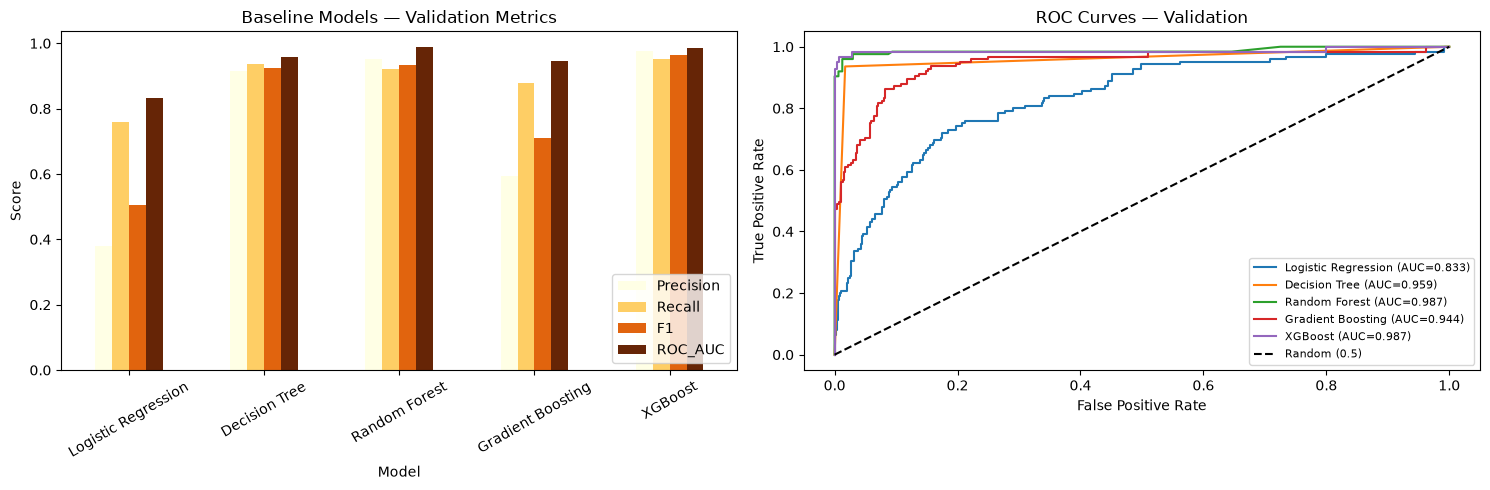

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Metrics comparison
baseline_df[['Precision','Recall','F1','ROC_AUC']].plot(
    kind='bar', ax=axes[0], colormap='YlOrBr')
axes[0].set_title('Baseline Models — Validation Metrics')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30)

# ROC curves
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1], [0,1], 'k--', label='Random (0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Validation')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\baseline_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

\Selecting top 2 model for hyperparameter tuning

In [10]:
# Rank by F1 
ranked = baseline_df.sort_values('F1', ascending=False)

print("RANKING by F1 (Validation):")
print(ranked[['F1','Recall','Precision','ROC_AUC']].to_string())

top_2 = ranked.head(2).index.tolist()
print(f"\n TOP 2 selected for hyperparameter tuning:")
for i, m in enumerate(top_2, 1):
    print(f"  {i}. {m}  (F1={ranked.loc[m,'F1']}, ROC-AUC={ranked.loc[m,'ROC_AUC']})")

RANKING by F1 (Validation):
                           F1  Recall  Precision   ROC_AUC
Model                                                     
XGBoost              0.963563   0.952   0.975410  0.986571
Random Forest        0.934959   0.920   0.950413  0.987232
Decision Tree        0.924901   0.936   0.914062  0.959420
Gradient Boosting    0.709677   0.880   0.594595  0.944300
Logistic Regression  0.505319   0.760   0.378486  0.832973

 TOP 2 selected for hyperparameter tuning:
  1. XGBoost  (F1=0.9635627530364372, ROC-AUC=0.9865709828393137)
  2. Random Forest  (F1=0.9349593495934959, ROC-AUC=0.9872324492979719)


\Hyperparameter tuning

In [ ]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

xgb_params = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 4, 5, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight,random_state=42,eval_metric ='logloss',n_jobs=-1)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_params,
    n_iter=30,             
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Tuning XGBoost")
xgb_search.fit(X_train, y_train)

print("\n XGBoost tuning done")
print("Best CV F1 :", round(xgb_search.best_score_, 4))
print("Best params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k:20s}: {v}")

Tuning XGBoost... (30 combos × 5 folds = 150 fits)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 XGBoost tuning done
Best CV F1 : 0.9181
Best params:
  subsample           : 0.8
  n_estimators        : 200
  min_child_weight    : 3
  max_depth           : 8
  learning_rate       : 0.2
  colsample_bytree    : 0.9


In [ ]:
# Gradient Boosting parameter
gb_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4]
}

gb_base = GradientBoostingClassifier(random_state=42)

gb_search = RandomizedSearchCV(
    gb_base, gb_params,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Tuning Gradient Boosting")
gb_search.fit(X_train, y_train, sample_weight=sample_weights)

print("\n Gradient Boosting tuning done")
print("Best CV F1 :", round(gb_search.best_score_, 4))
print("Best params:")
for k, v in gb_search.best_params_.items():
    print(f"  {k:20s}: {v}")

Tuning Gradient Boosting... (may take 2-3 min)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Gradient Boosting tuning done
Best CV F1 : 0.9369
Best params:
  subsample           : 0.9
  n_estimators        : 200
  min_samples_split   : 2
  min_samples_leaf    : 4
  max_depth           : 3
  learning_rate       : 0.2
